# analysis.organism-range

In this notebook we will study the *organism range*, a property that could be seen as the analogue of organism *host-range* in hosts. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from daforfer import DaforferDB
import powerlaw
import networkx as nx
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
si = DaforferDB(conf['si'])
si.toc()

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


┌──────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│   name   │                                                        description                                                        │
│ varchar  │                                                          varchar                                                          │
├──────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ TableS1  │ Table S1: Library sites and context                                                                                       │
│ TableS2  │ This table summarizes most of the information of our detected OTUs, including host_range, site_range, habitat_range, etc. │
│ TableS3  │ Site-level diversity and number of cooccurring virus-bacteria                                                             │
│ TableS4  │ Habitat-level diversity and 

## Load data

In [2]:
metadata = db.conn.sql('SELECT * FROM D_sites').df()
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()

# bacteria_hits = pd.read_csv("output/hits.bacteria.csv", sep=";").query("is_pab==True")
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left')#.dropna(subset='taxid')
# bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)

# virus_hits = pd.read_csv("output/hits.virus.csv", sep=";")
virus_hits = pd.merge(metadata, virus_hits, on='library', how='left')#.dropna(subset='taxid')
# virus_hits['taxid'] = virus_hits['taxid'].astype(int)

## Organism range calculation

In [3]:

host_bacteria_range = bacteria_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().value_counts(
        ['host_taxon']
    ).reset_index().rename(columns={'count': 'bacteria_range'})

host_bacteria_range

,host_taxon,bacteria_range
0,Conyza bonariensis,43
1,Bromus sp,37
2,Convolvulus arvensis,37
3,Amaranthus sp,17
4,Diplotaxis erucoides,17
...,...,...
70,Lavandula latifolia,1
71,Lithodora fruticosa,1
72,Marrubium vulgare,1
73,Phlomis lychnitis,1


In [4]:
host_virus_range = virus_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().value_counts(
        ['host_taxon']
    ).reset_index().rename(columns={'count': 'virus_range'})
host_virus_range

,host_taxon,virus_range
0,Diplotaxis erucoides,41
1,Picris echioides,35
2,Convolvulus arvensis,32
3,Amaranthus sp,32
4,Rubia peregrina,32
...,...,...
101,Dittrichia viscosa,1
102,Borago officinalis,1
103,Aphyllanthes monspeliensis,1
104,Melilotus sp,1


In [5]:
organism_range = pd.merge(host_bacteria_range, host_virus_range, on='host_taxon', how='outer').fillna(0)
# WE will save this dataframe later
organism_range

,host_taxon,bacteria_range,virus_range
0,Allium sativum,0.0,4.0
1,Amaranthus sp,17.0,32.0
2,Anacyclus clavatus,7.0,14.0
3,Anchusa undulata,5.0,19.0
4,Andryala arenaria,5.0,3.0
...,...,...,...
108,Trifolium tomentosum,1.0,2.0
109,Verbascum sinuatum,8.0,10.0
110,Vicia sp,7.0,20.0
111,Xanthium strumarium,0.0,2.0


Below, we will visualize the organisms range using a histogram.

In [6]:
organism_range_melt = organism_range.melt(id_vars=['host_taxon'], value_vars=['bacteria_range', 'virus_range'])
organism_range_melt['variable'] = organism_range_melt['variable'].apply(lambda x: x.replace("_range", ""))
organism_range_melt = organism_range_melt.rename(columns={'variable':'kingdom', 'value':'range'})
organism_range_melt

,host_taxon,kingdom,range
0,Allium sativum,bacteria,0.0
1,Amaranthus sp,bacteria,17.0
2,Anacyclus clavatus,bacteria,7.0
3,Anchusa undulata,bacteria,5.0
4,Andryala arenaria,bacteria,5.0
...,...,...,...
221,Trifolium tomentosum,virus,2.0
222,Verbascum sinuatum,virus,10.0
223,Vicia sp,virus,20.0
224,Xanthium strumarium,virus,2.0


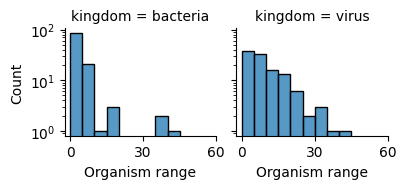

In [7]:

max_range = (organism_range_melt['range'].max() // 5) + 2
bins = np.arange(0, max_range * 5, 5)
g = sns.displot(data=organism_range_melt, x='range', col='kingdom', height=2.0, bins=bins)
g.axes[0, 0].set_yscale('log')
g.axes[0, 0].set_xticks([0, 30, 60])
g.set_xlabels("Organism range")
g.set_ylabels("Count")
g.savefig("figures/displot.organism-range.colbykingdom.svg")

## Host range distribution

In [8]:
heavy_tail_model_lrtest = []

pwl_virus = powerlaw.Fit(data=organism_range_melt.query('kingdom == "virus"').query('range > 0')['range'].values, discrete=True)
pwl_bacteria = powerlaw.Fit(data=organism_range_melt.query('kingdom == "bacteria"').query('range > 0')['range'].values, discrete=True)

R, p = pwl_virus.distribution_compare('power_law', 'exponential')
heavy_tail_model_lrtest.append({'distribution':'virus', 'dist1': 'power-law', 'dist2': 'exponential', 'R':R, 'p-value':p})
R, p = pwl_virus.distribution_compare('lognormal', 'exponential')
heavy_tail_model_lrtest.append({'distribution':'virus', 'dist1': 'lognormal', 'dist2': 'exponential', 'R':R, 'p-value':p})
R, p = pwl_bacteria.distribution_compare('power_law', 'exponential')
heavy_tail_model_lrtest.append({'distribution':'bacteria', 'dist1': 'power-law', 'dist2': 'exponential', 'R':R, 'p-value':p})
R, p = pwl_bacteria.distribution_compare('lognormal', 'exponential')
heavy_tail_model_lrtest.append({'distribution':'bacteria', 'dist1': 'lognormal', 'dist2': 'exponential', 'R':R, 'p-value':p})
heavy_tail_model_lrtest = pd.DataFrame.from_records(heavy_tail_model_lrtest)

db.save_dataframe(
    heavy_tail_model_lrtest, table_name="T_orgRangeslogRatioTest", description="Power-law, Lognormal, and Exponential fit log-ratio test"
)

heavy_tail_model_lrtest

Calculating best minimal value for power law fit
Calculating best minimal value for power law fit
Saved T_orgRangeslogRatioTest to db.2025-10-27


,distribution,dist1,dist2,R,p-value
0,virus,power-law,exponential,-0.185868,0.813662
1,virus,lognormal,exponential,0.018679,0.960261
2,bacteria,power-law,exponential,4.035624,0.071681
3,bacteria,lognormal,exponential,4.090937,0.048627


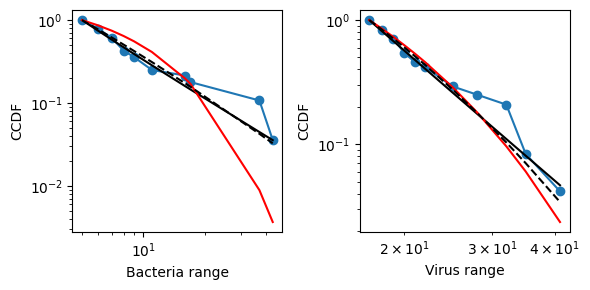

In [9]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(6, 3)
pwl_bacteria.plot_ccdf(ax=ax[0], marker='o')
pwl_bacteria.power_law.plot_ccdf(ax=ax[0], color='black', linestyle='-')
pwl_bacteria.exponential.plot_ccdf(ax=ax[0], color='red', linestyle='-')
pwl_bacteria.lognormal.plot_ccdf(ax=ax[0], color='black', linestyle='--')

pwl_virus.plot_ccdf(ax=ax[1], marker='o')
pwl_virus.power_law.plot_ccdf(ax=ax[1], color='black', linestyle='-')
pwl_virus.exponential.plot_ccdf(ax=ax[1], color='red', linestyle='-')
pwl_virus.lognormal.plot_ccdf(ax=ax[1], color='black', linestyle='--')

# ax[0].set_title("Bacteria range")
# ax[1].set_title("Virus range ")

ax[0].set_xlabel("Bacteria range")
ax[1].set_xlabel("Virus range")

ax[0].set_ylabel("CCDF")
ax[1].set_ylabel("CCDF")

fig.tight_layout()
# fig.savefig("figures/ccdfplot.host-range-distributions.svg")

## Regression analysis between bacteria and virus range

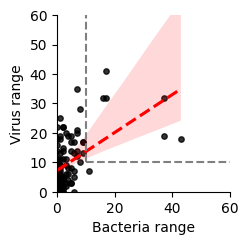

In [10]:
g = sns.lmplot(data=organism_range, x='bacteria_range', y='virus_range', height=2.5,  scatter_kws={'color':'black', 's':15}, line_kws={'color':'red', 'linestyle':'--'})
g.set_xlabels("Bacteria range")
g.set_ylabels("Virus range")
g.ax.set_xlim(0, 60)
g.ax.set_ylim(0, 60)
g.ax.axvline(10, ymin=0.17, ymax=1.0, color='gray', linestyle='--')
g.ax.axhline(10, xmin=0.17, xmax=1.0, color='gray', linestyle='--')
g.savefig("figures/linreg.bact-range.virus-range.svg")

In [11]:
test_1 = stats.linregress(organism_range['bacteria_range'], organism_range['virus_range'])

test_1_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Regression between bacteria and virus range"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":"No correlation between number of libraries and species richness"},
    {"key": "H1", "value":"Correlation between number of libraries and species richness"},
    {"key": "p-value", "value": test_1.pvalue}, # type: ignore
    {"key": "significative", "value": test_1.pvalue < 0.05}, # type: ignore
    {"key": "intercept", "value": test_1.intercept}, # type: ignore
    {"key": "slope", "value": test_1.slope}, # type: ignore
    {"key": "r-value", "value": test_1.rvalue}, # type: ignore
    {"key": "R2", "value": test_1.rvalue ** 2} # type: ignore

])

db.save_dataframe(test_1_results, "T_orgRangeCorr", "Regression between bacteria and virus range")
test_1_results



Saved T_orgRangeCorr to db.2025-10-27


,key,value
0,title,Regression between bacteria and virus range
1,test-type,Regression
2,H0,No correlation between number of libraries and...
3,H1,Correlation between number of libraries and sp...
4,p-value,0.0
5,significative,True
6,intercept,7.185993
7,slope,0.644957
8,r-value,0.520995
9,R2,0.271436


## Computing total organism range

In [12]:
organism_range['total'] = organism_range['bacteria_range'] + organism_range['virus_range']
organism_range.sort_values(by='total', ascending=False)

,host_taxon,bacteria_range,virus_range,total
27,Convolvulus arvensis,37.0,32.0,69.0
28,Conyza bonariensis,43.0,18.0,61.0
40,Diplotaxis erucoides,17.0,41.0,58.0
21,Bromus sp,37.0,19.0,56.0
1,Amaranthus sp,17.0,32.0,49.0
...,...,...,...,...
13,Astragalus sesameus,1.0,0.0,1.0
43,Dittrichia viscosa,0.0,1.0,1.0
61,Lavandula latifolia,1.0,0.0,1.0
64,Lithodora fruticosa,1.0,0.0,1.0


## Cooccurrences at host level

Now, let's also include whether these organisms also include a higher number of cooccurrences. We will load first the cooccurrence network

In [13]:
G = nx.read_graphml("output/network.coocurrence.virusbact-bylibrary.trans.graphml")
#nx.draw(G)
G.nodes(data=True)

NodeDataView({'Beet chlorosis virus': {}, 'Duffyella gerundensis': {}, 'Frigoribacterium sp. Leaf164': {}, 'Pseudomonas oryzihabitans': {}, 'Rhodococcoides fascians': {}, 'Beet mild yellowing virus': {}, 'Beet western yellows virus': {}, 'Agrobacterium tumefaciens': {}, 'Arthrobacter sp. Leaf234': {}, 'Pseudomonas sp. Leaf127': {}, 'Sphingomonas sp. Leaf20': {}, 'Cucumber mosaic virus RNA 3': {}, 'Maize dwarf mosaic virus': {}, 'Parietaria mottle virus RNA 3': {}, 'Xanthomonas campestris': {}, 'Pelargonium zonate spot virus RNA 3': {}, 'Pepper mild mottle virus': {}, 'Frigoribacterium sp. Leaf186': {}, 'Pantoea ananatis': {}, 'Sanguibacter sp. Leaf3': {}, 'Rubus chlorotic mottle virus': {}, 'Tobacco mild green mosaic virus': {}, 'Methylobacterium sp. Leaf125': {}, 'Pseudomonas punonensis': {}, 'Rhizobium sp. Leaf311': {}, 'Sphingomonas sp. Leaf208': {}, 'Xylophilus sp. Leaf220': {}, 'Tobacco mosaic virus': {}, 'Curtobacterium flaccumfaciens': {}, 'Rhizobium sp. NFR03': {}, 'Tomato aspe

Now, we need to count the number of cooccurrences in each host. For that, first we need to get whole lists of all the organisms detected in a given host. For that, we will convert all organisms detected in a given host into a list. 

In [14]:

host_bacteria_range_scientific_name = bacteria_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().groupby(
        ['host_taxon'], as_index=False
    )['scientific_name'].apply(list)

host_virus_range_scientific_name = virus_hits.value_counts(
    ['host_taxon', 'scientific_name']
    ).reset_index().groupby(
        ['host_taxon'], as_index=False
    )['scientific_name'].apply(list)

host_organism_range_scientific_name = pd.merge(host_bacteria_range_scientific_name, host_virus_range_scientific_name, on='host_taxon')
host_organism_range_scientific_name

,host_taxon,scientific_name_x,scientific_name_y
0,Amaranthus sp,"[Arthrobacter sp. Leaf234, Rhodococcoides fasc...","[Rubus chlorotic mottle virus, Watermelon mosa..."
1,Anacyclus clavatus,"[Rhodococcoides fascians, Pseudomonas oryzihab...","[Pelargonium zonate spot virus RNA 3, Cucumber..."
2,Anchusa undulata,"[Chryseobacterium sp. Leaf201, Aureimonas sp. ...","[Rubus chlorotic mottle virus, Pelargonium zon..."
3,Andryala arenaria,"[Ralstonia sp. MD27, Pseudomonas lutea, Methyl...","[Arabidopsis latent virus-1 RNA1, Tobacco mild..."
4,Anthriscus caucalis,[Methylobacterium sp. Leaf125],"[Tomato aspermy virus RNA 3, Pelargonium zonat..."
...,...,...,...
63,Tragopogon sp,[Duffyella gerundensis],"[African eggplant yellowing virus, Beet chloro..."
64,Trifolium tomentosum,[Pseudomonas lutea],"[Barley yellow dwarf virus - PAS, Barley yello..."
65,Verbascum sinuatum,"[Rhodococcoides fascians, Curtobacterium flacc...","[Cucumber mosaic virus RNA 3, Tobacco mosaic v..."
66,Vicia sp,"[Frigoribacterium sp. Leaf186, Duffyella gerun...","[Pelargonium zonate spot virus RNA 3, Cucumber..."


Now, we can make subnetworks out of the original network, and simply count the number of edges.

In [15]:
host_organism_range_scientific_name['network'] = host_organism_range_scientific_name.apply(
    lambda x: G.subgraph(x.scientific_name_x + x.scientific_name_y), axis=1
)
host_organism_range_scientific_name['n_cooccurrences'] = host_organism_range_scientific_name['network'].apply(lambda x: x.number_of_edges())
host_organism_range_scientific_name

,host_taxon,scientific_name_x,scientific_name_y,network,n_cooccurrences
0,Amaranthus sp,"[Arthrobacter sp. Leaf234, Rhodococcoides fasc...","[Rubus chlorotic mottle virus, Watermelon mosa...","(Beet chlorosis virus, Duffyella gerundensis, ...",35
1,Anacyclus clavatus,"[Rhodococcoides fascians, Pseudomonas oryzihab...","[Pelargonium zonate spot virus RNA 3, Cucumber...","(Tobacco mild green mosaic virus, Duffyella ge...",9
2,Anchusa undulata,"[Chryseobacterium sp. Leaf201, Aureimonas sp. ...","[Rubus chlorotic mottle virus, Pelargonium zon...","(Pseudomonas lutea, Tobacco mild green mosaic ...",4
3,Andryala arenaria,"[Ralstonia sp. MD27, Pseudomonas lutea, Methyl...","[Arabidopsis latent virus-1 RNA1, Tobacco mild...","(Pseudomonas lutea, Tobacco mild green mosaic ...",3
4,Anthriscus caucalis,[Methylobacterium sp. Leaf125],"[Tomato aspermy virus RNA 3, Pelargonium zonat...","(Tobacco mosaic virus, Beet western yellows vi...",0
...,...,...,...,...,...
63,Tragopogon sp,[Duffyella gerundensis],"[African eggplant yellowing virus, Beet chloro...","(Duffyella gerundensis, Pepper mild mottle vir...",3
64,Trifolium tomentosum,[Pseudomonas lutea],"[Barley yellow dwarf virus - PAS, Barley yello...",(Pseudomonas lutea),0
65,Verbascum sinuatum,"[Rhodococcoides fascians, Curtobacterium flacc...","[Cucumber mosaic virus RNA 3, Tobacco mosaic v...","(Tobacco mosaic virus, Watermelon mosaic virus...",3
66,Vicia sp,"[Frigoribacterium sp. Leaf186, Duffyella gerun...","[Pelargonium zonate spot virus RNA 3, Cucumber...","(Beet chlorosis virus, Duffyella gerundensis, ...",23


In [16]:
organism_range = pd.merge(organism_range, host_organism_range_scientific_name[['host_taxon', 'n_cooccurrences']], on='host_taxon', how='outer').fillna(0)
organism_range['all_possible_cooccurrences'] = organism_range['bacteria_range'] * organism_range['virus_range']
organism_range = pd.merge(organism_range, metadata[['host_taxon', 'habitat']].drop_duplicates().groupby('host_taxon', as_index=False)['habitat'].apply(lambda x: ", ".join(list(x))), on='host_taxon')
db.save_dataframe(
    organism_range, table_name="D_organismRange", 
    description="Hosts bacteria and virus ranges"
)
si.save_dataframe(
    organism_range, table_name="Table10", 
    description="Hosts bacteria and virus ranges"
)
organism_range

Saved D_organismRange to db.2025-10-27
Saved Table10 to si.2025-10-27


,host_taxon,bacteria_range,virus_range,total,n_cooccurrences,all_possible_cooccurrences,habitat
0,Allium sativum,0.0,4.0,4.0,0.0,0.0,Edge
1,Amaranthus sp,17.0,32.0,49.0,35.0,544.0,"Edge, Crop"
2,Anacyclus clavatus,7.0,14.0,21.0,9.0,98.0,"Wasteland, Crop, Edge"
3,Anchusa undulata,5.0,19.0,24.0,4.0,95.0,"Wasteland, Edge"
4,Andryala arenaria,5.0,3.0,8.0,3.0,15.0,Oak
...,...,...,...,...,...,...,...
108,Trifolium tomentosum,1.0,2.0,3.0,0.0,2.0,Wasteland
109,Verbascum sinuatum,8.0,10.0,18.0,3.0,80.0,Wasteland
110,Vicia sp,7.0,20.0,27.0,23.0,140.0,"Wasteland, Edge"
111,Xanthium strumarium,0.0,2.0,2.0,0.0,0.0,Crop


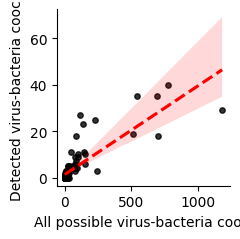

In [17]:
g = sns.lmplot(data=organism_range, x='all_possible_cooccurrences', y='n_cooccurrences', height=2.5,  scatter_kws={'color':'black', 's':15}, line_kws={'color':'red', 'linestyle':'--'})
g.set_xlabels("All possible virus-bacteria cooc.")
g.set_ylabels("Detected virus-bacteria cooc.")

In [18]:
test_2 = stats.linregress(organism_range['all_possible_cooccurrences'], organism_range['n_cooccurrences'])

test_2_results = pd.DataFrame.from_records([
    {"key": "title", "value":"Possible cooccurrences versus detected cooccurrences"},
    {"key": "test-type", "value":"Regression"},
    {"key": "H0", "value":"No correlation between number of libraries and species richness"},
    {"key": "H1", "value":"Correlation between number of libraries and species richness"},
    {"key": "p-value", "value": test_2.pvalue}, #type: ignore
    {"key": "significative", "value": test_2.pvalue < 0.05}, #type: ignore
    {"key": "intercept", "value": test_2.intercept}, #type: ignore
    {"key": "slope", "value": test_2.slope}, #type: ignore
    {"key": "r-value", "value": test_2.rvalue}, #type: ignore
    {"key": "R2", "value": test_2.rvalue ** 2} #type: ignore

])

db.save_dataframe(
    test_2_results, table_name="T_hostCooc", 
    description="Correlation test between possible cooccurences and detected cooccurences at host level"
)
test_2_results


Saved T_hostCooc to db.2025-10-27


,key,value
0,title,Possible cooccurrences versus detected cooccur...
1,test-type,Regression
2,H0,No correlation between number of libraries and...
3,H1,Correlation between number of libraries and sp...
4,p-value,0.0
5,significative,True
6,intercept,1.392036
7,slope,0.038099
8,r-value,0.829563
9,R2,0.688175


In [19]:
db.conn.close()
si.conn.close()